# Obligatorio - Taller de Inteligencia Artificial 2025

## Ramiro Sanes (368397) - Joaquin Guerra (307854)

En este caso entrenamos únicamente el **agente DDQN**, utilizando una replay memory priorizada con un buffer size mayor y durante más episodios buscando mejorar la performance obtenida por los anteriores agentes con memoria priorizada.
La decisión de entrenar solamente el DDQN se basa en que los resultados obtenidos hasta ahora fueron utilizando esta tecnica y los tiempos de sampleo de la memoria priorizada más grande hacen que el tiempo total de entrenamiento sea mucho mayor.

In [1]:
import os
import torch
import numpy as np
import random
import numpy as np
import gymnasium
import ale_py
from IPython.display import Video

from utils import make_env, process_state, show_observation_stack, plot_rewards_and_max_values
from dqn_agent import DQNAgent
from dqn_cnn_model import DQN_CNN_Model
from double_dqn_agent import DoubleDQNAgent

In [2]:
SEED = 23

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic=True # https://discuss.pytorch.org/t/what-is-the-differenc-between-cudnn-deterministic-and-cudnn-benchmark/38054
torch.backends.cudnn.benchmark=True # https://discuss.pytorch.org/t/what-does-torch-backends-cudnn-benchmark-do/5936/4
np.random.seed(SEED)
random.seed(SEED)

In [3]:
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"  
elif torch.backends.mps.is_available():
    DEVICE = "mps" 

In [4]:
GRAY_SCALE = True 
SCREEN_SIZE = 84 
NUM_STACKED_FRAMES = 4 
SKIP_FRAMES = 4 
ENV_NAME = "ALE/Breakout-v5" 

Seteamos el BUFFER_SIZE en 30.000 y la cantidad de episodios en 10.000

In [5]:
#Hiperparámetros de entrenamiento del agente DQN
TOTAL_STEPS = 10_000_000
EPISODES = 10_000
STEPS_PER_EPISODE = 20_000

EPSILON_INI = 1
EPSILON_MIN = 0.05
EPSILON_ANNEAL_STEPS = 1_000_000

EPISODE_BLOCK = 100

BATCH_SIZE = 32
BUFFER_SIZE = 30_000

GAMMA = 0.995
LEARNING_RATE = 1e-5

In [7]:
env = make_env(ENV_NAME,
                video_folder='./videos/dqn_training_prio',
                name_prefix="breakout",
                record_every=500,
                grayscale=GRAY_SCALE,
                screen_size=SCREEN_SIZE,
                stack_frames=NUM_STACKED_FRAMES,
                skip_frames=SKIP_FRAMES
                )

net = DQN_CNN_Model(env.observation_space.shape, env.action_space.n).to(DEVICE)

dqn_agent_prio = DQNAgent(env, net, process_state, BUFFER_SIZE, BATCH_SIZE, LEARNING_RATE, GAMMA, 
                     epsilon_i=EPSILON_INI, epsilon_f=EPSILON_MIN, 
                     epsilon_anneal_steps=EPSILON_ANNEAL_STEPS, 
                     episode_block=EPISODE_BLOCK, device=DEVICE, with_priority= True)



A.L.E: Arcade Learning Environment (version 0.11.1+2750686)
[Powered by Stella]


Generamos una lista con 10 estados procesados al azar, para evaluar el valor de las funciones en esos estados durante el entrenamiento.

In [8]:
state_eval_list = []
for _ in range(10):
    state_eval_list.append(process_state(env.reset()[0],DEVICE))


### Entrenamos al agente DoubleDQNAgent y medimos sus resultados

In [9]:
env = make_env(ENV_NAME,
                video_folder='./videos/ddqn_training_prio',
                name_prefix="breakout",
                record_every=500,
                grayscale=GRAY_SCALE,
                screen_size=SCREEN_SIZE,
                stack_frames=NUM_STACKED_FRAMES,
                skip_frames=SKIP_FRAMES
                )

net = DQN_CNN_Model(env.observation_space.shape, env.action_space.n).to(DEVICE)
target_net = DQN_CNN_Model(env.observation_space.shape, env.action_space.n).to(DEVICE)

double_dqn_agent_prio = DoubleDQNAgent(env, net,target_net, process_state, BUFFER_SIZE, BATCH_SIZE, LEARNING_RATE, GAMMA, 
                     epsilon_i=EPSILON_INI, epsilon_f=EPSILON_MIN, 
                     epsilon_anneal_steps=EPSILON_ANNEAL_STEPS, 
                     episode_block=EPISODE_BLOCK, device=DEVICE, with_priority= True)



In [10]:
rewards_2, state_values_2 = double_dqn_agent_prio.train(EPISODES, STEPS_PER_EPISODE, TOTAL_STEPS,random_states = state_eval_list)

Training:  10%|█         | 1000/10000 [35:53<5:13:17,  2.09s/episode, reward=1.76, epsilon=0.836, steps=172661]

Checkpoints saved to weights/ddqn_prio/checkpoint_1000_policy_net.pth and weights/ddqn_prio/checkpoint_1000_target_net.pth


Training:  20%|██        | 2000/10000 [1:21:46<9:25:28,  4.24s/episode, reward=3.23, epsilon=0.638, steps=381105]

Checkpoints saved to weights/ddqn_prio/checkpoint_2000_policy_net.pth and weights/ddqn_prio/checkpoint_2000_target_net.pth


Training:  30%|███       | 3000/10000 [2:23:55<6:19:39,  3.25s/episode, reward=5.9, epsilon=0.354, steps=679763]  

...

Checkpoints saved to weights/ddqn_prio/checkpoint_8000_policy_net.pth and weights/ddqn_prio/checkpoint_8000_target_net.pth


Training:  90%|█████████ | 9000/10000 [12:55:18<2:03:37,  7.42s/episode, reward=11.8, epsilon=0.05, steps=3908891]

Checkpoints saved to weights/ddqn_prio/checkpoint_9000_policy_net.pth and weights/ddqn_prio/checkpoint_9000_target_net.pth


Training: 100%|██████████| 10000/10000 [14:51:06<00:00,  5.35s/episode, reward=12.3, epsilon=0.05, steps=4481220] 

Checkpoints saved to weights/ddqn_prio/checkpoint_10000_policy_net.pth and weights/ddqn_prio/checkpoint_10000_target_net.pth


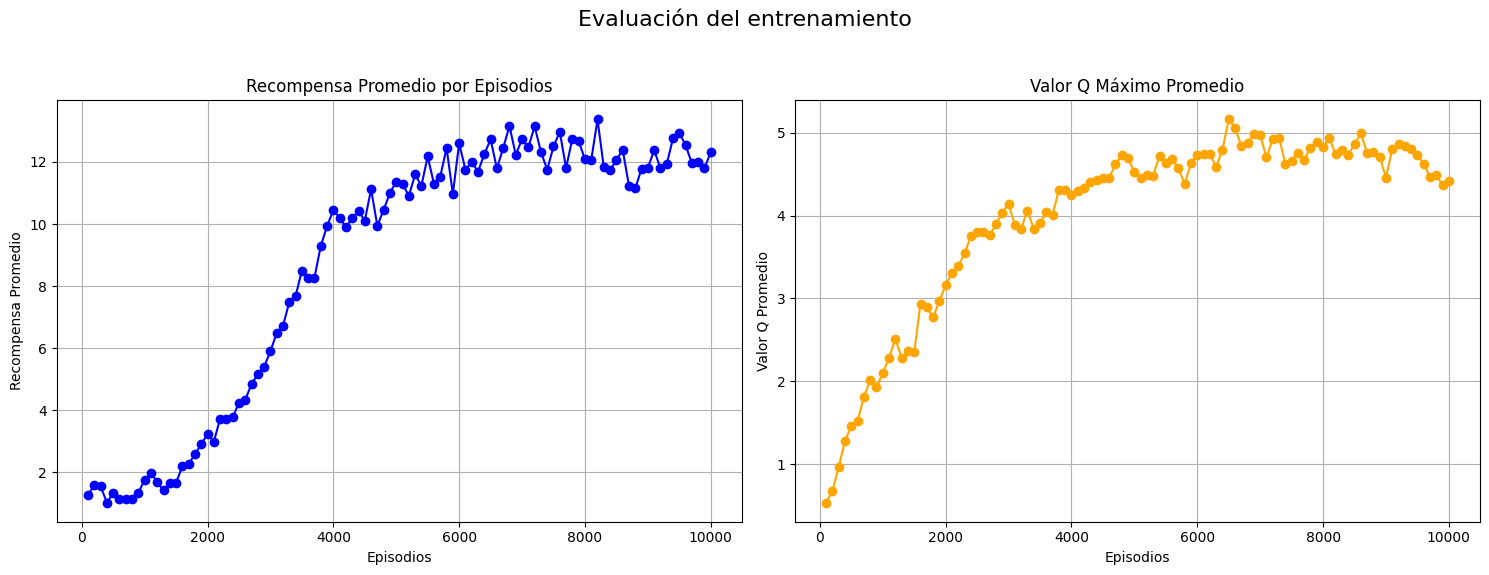

In [11]:
plot_rewards_and_max_values(rewards_2, state_values_2, "Double DQN Agent con Memoria Priorizada", "Evaluación del entrenamiento",)

Hacemos que el agente juegue 10 episodios y mostramos el desempeño

In [13]:

env = make_env(ENV_NAME,
                video_folder='./videos/ddqn_test_prio',
                name_prefix="breakout",
                record_every=1,
                grayscale=GRAY_SCALE,
                screen_size=SCREEN_SIZE,
                stack_frames=NUM_STACKED_FRAMES,
                skip_frames=SKIP_FRAMES
                )

checkpoint_path = "checkpoint_10000"
print(f"Cargando checkpoint desde {checkpoint_path}")
double_dqn_agent_prio.load_checkpoint(checkpoint_path,True)

retornos = double_dqn_agent_prio.play(env=env, episodes=10)


video_path = f"./videos/ddqn_test_prio/breakout-episode-{retornos.argmax()}.mp4"

print(f"El agente DoubleDQNAgent con Memoria Priorizada obtuvo un retorno promedio de {retornos.mean()} en {len(retornos)} episodios. \n Y el mejor retorno fue {retornos.max()} en el episodio {retornos.argmax()}.")

# Muestra el vídeo
Video(video_path, embed=True, width=600)

Cargando checkpoint desde checkpoint_10000
Checkpoints loaded from weights/ddqn_prio/checkpoint_10000_policy_net.pth and weights/ddqn_prio/checkpoint_10000_target_net.pth
El agente DoubleDQNAgent con Memoria Priorizada obtuvo un retorno promedio de 13.9 en 10 episodios. 
 Y el mejor retorno fue 19.0 en el episodio 3.
